# Multidimensional Regression with NNs 

We want to approximate the following unkown (multidimensional scalar real-valued) function $f\colon D \subset \mathbb{R}^d \rightarrow \mathbb{R}$ with a neural network model given input-output $K$ pairs $(x^{(k)}, y^{(k)})_{k=1}^K$ of the data. 

Import dependencies

In [1]:
import sys; sys.path.append('../src/playground_jax')
from time import time

import matplotlib.pyplot as plt
import numpy as np
import jax
from jax import numpy as jnp
from jaxtyping import Array, PyTree
import optax
from sklearn.metrics import r2_score

jax.config.update("jax_enable_x64", True)

Define *target function*. For instance, $(x_1, x_2) \mapsto f(x_1, x_2) = x_1^2 + x_2^2$

In [2]:
def f_fn(x1, x2):
    return x1**2 + x2**2

Get training data by using the discretized 2-dimensional grid as the input

In [3]:
# set n points per axis
N = 101

# set bounds
x_min, x_max = -1, 1

# create grid
x1 = x2 = jnp.linspace(x_min, x_max, N)
x1_mesh, x2_mesh = jnp.meshgrid(x1, x2, indexing='ij')
x = jnp.stack((x1_mesh, x2_mesh))
x = jnp.moveaxis(x, 0, -1)
x_train = jnp.reshape(x, (N*N, 2))
    
# evaluate on grid
y = f_fn(x1_mesh, x2_mesh)
y_train = jnp.reshape(y, (N*N, 1))
x_train.shape, y_train.shape

((10201, 2), (10201, 1))

Visualize target function

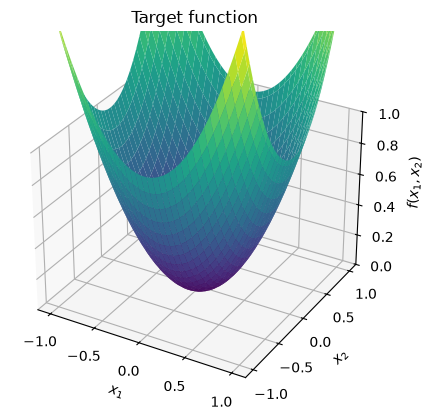

In [4]:
fig, ax = plt.subplots(subplot_kw={"projection": "3d"})
ax.plot_surface(x1_mesh, x2_mesh, y_train.reshape(x1_mesh.shape), cmap='viridis')
ax.set_zlim(0,1)
ax.set_xlabel('$x_1$',fontsize=10)
ax.set_ylabel('$x_2$',fontsize=10)
ax.set_zlabel('$f(x_1,x_2)$',fontsize=10)
ax.set_title('Target function');

Build a _multilayer perceptron (MLP)_ feedforward neural network
1. Define method to initialize the model parameters

In [5]:
def init_mlp_params(layer_widths: list) -> list[dict]:
    '''
    Initializes parameters for an MLP and returns them
    wrapped in a list.
    '''
    params = []
    for n_in, n_out in zip(layer_widths[:-1], layer_widths[1:]):
        # weights and bias for each layer
        params.append(
            dict(
                weights=np.random.normal(size=(n_in, n_out)) * np.sqrt(2 / n_in),
                biases=np.ones(shape=(n_out,))
            )
        )
    return params

2. Set neural network architecture and initialize parameters

In [6]:
# set input, output and hidden dimensions
d_in, d_hiddens, d_out = 2, [32, 16, 8], 1
params = init_mlp_params([d_in] + d_hiddens + [d_out])

# check shapes
jax.tree_util.tree_map(lambda x: x.shape, params)

[{'biases': (32,), 'weights': (2, 32)},
 {'biases': (16,), 'weights': (32, 16)},
 {'biases': (8,), 'weights': (16, 8)},
 {'biases': (1,), 'weights': (8, 1)}]

3. Define forward method for the model

In [8]:
@jax.jit
def forward(params: list, x: Array, activation=jax.nn.tanh, 
            final_activation=lambda x: x) -> Array:
    '''
    Performs a forward pass
    '''
    *hidden, last = params
    for layer in hidden:
        x = activation(x @ layer['weights'] + layer['biases'])
    return final_activation(x @ last['weights'] + last['biases'])

Define MSE loss

In [9]:
@jax.jit
def loss_fn(params: list, x: Array, y: Array) -> Array:
    '''
    Implements Mean Square Loss
    '''
    return jnp.mean((forward(params, x) - y)**2)

Define train step function method

In [10]:
@jax.jit
def train_step(params: list, opt_state: PyTree, x: Array, y: Array) -> list:
    '''
    Evaluates loss, computes gradients and updates parameters using the chosen optimizer.
    '''
    # evaluate loss and compute gradients
    loss_value, grads = jax.value_and_grad(loss_fn)(params, x, y)

    # compute the updates following the chosen optimizer's rule
    updates, opt_state = opt.update(grads, opt_state)

    # update parameters
    params = optax.apply_updates(params, updates)
    
    return params, opt_state, loss_value

Define optimizer via optax and initialize parameters

In [11]:
lr = 1e-2
opt = optax.adam(lr)
params = init_mlp_params([d_in] + d_hiddens + [d_out])
opt_state = opt.init(params)

Train

In [12]:
n_iter = int(1e4)
log_period_iter = int(1e3)
for i in range(n_iter):
    t0 = time()
    params, opt_state, loss_value = train_step(params, opt_state, x_train, y_train)
    t1 = time()
    if i % log_period_iter  == 0: 
        print('it: {:d}, loss: {:.3e}, time: {:.4f}s'.format(i, loss_value, t1-t0))

it: 0, loss: 7.113e-01, time: 0.2110s
it: 1000, loss: 1.775e-04, time: 0.0017s
it: 2000, loss: 2.706e-05, time: 0.0018s
it: 3000, loss: 2.065e-05, time: 0.0017s
it: 4000, loss: 1.116e-05, time: 0.0017s
it: 5000, loss: 6.884e-06, time: 0.0017s
it: 6000, loss: 6.469e-06, time: 0.0016s
it: 7000, loss: 2.383e-05, time: 0.0017s
it: 8000, loss: 4.640e-06, time: 0.0017s
it: 9000, loss: 4.932e-06, time: 0.0016s


Evaluate results

In [13]:
y_pred = forward(params, x_train)
y_pred.shape

(10201, 1)

Compute _r2 score_

In [14]:
r2 = round(float(r2_score(y_train, y_pred)), 4)
print("R^2 Score:", r2)

R^2 Score: 0.9999


Visualize target function $f$ and trained MLP model $\varphi_\theta$

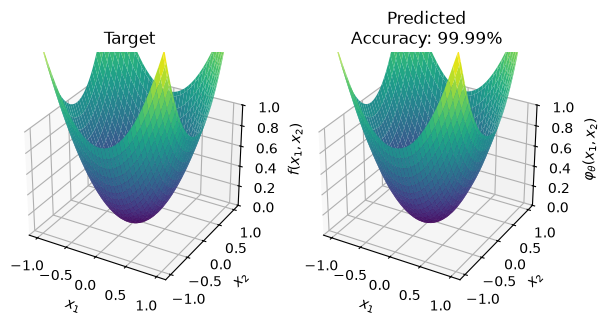

In [15]:
fig = plt.figure()

# Target function
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(x1_mesh, x2_mesh, y_train.reshape(x1_mesh.shape), cmap='viridis')
ax1.set_zlim(0,1)
ax1.set_xlabel('$x_1$',fontsize=10)
ax1.set_ylabel('$x_2$',fontsize=10)
ax1.set_zlabel('$f(x_1, x_2)$',fontsize=10)
ax1.set_title('Target ')

# Predictions
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(x1_mesh, x2_mesh, y_pred.reshape(x1_mesh.shape), cmap='viridis')
ax2.set_zlim(0,1)
ax2.set_xlabel('$x_1$',fontsize=10)
ax2.set_ylabel('$x_2$',fontsize=10)
ax2.set_zlabel(r'$\varphi_\theta(x_1,x_2)$',fontsize=10)
ax2.set_title(f' Predicted \nAccuracy: {round(r2*100, 4)}%')

# Show the plot
plt.tight_layout(pad=3.7)